##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** [Databazen🤓]

**Student names & numbers:**
* [Xander UijtdeHaag] - [Student no.100546]
* [Jamie Eversdijk] - [Student no.000101617]
* [Jero den Exter] - [Student no.000100883]


---

## 0. Iteration setup

**Import libraries**

In [76]:
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**Load and merge datasets**

Wij hebben besloten de eerste dataset de oude en opgeschoonde dataset te mergen door middel van een left join met de nieuwe dataset de tweede. Dit leek ons het meest logisch omdat je bij een left join die wij hebben gebruikt de eerste dataset alle rijen blijft houden. De rijen uit de tweede dataset in ons geval de nieuwe worden alleen toegevoegd als de Ship_ID in bijde datasets hetzelfde is. Als er een nieuwe Ship_ID in de nieuwe dataset zit wordt die ingevuld met een NAN. De nieuwe kolommen van de tweede dataset worden wel meegenomen. 

Een right join zou ook hebben gekunt maar dan zouden de datasets omgedraaid moeten worden dus df1 zou dan de nieuwe moeten zijn en df2 zou dan de oude clean dataset moeten zijn. 

Een inner join hebben wij niet gedaaan omdat dat alleen de data van de ship_ID pakt die in beide datasets staat. Dit zou onnodige ids verwijderen die wij er nu wel in hebben van de oude schone dataset.

In [25]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
# Merge them together based on the Ship_ID.
df1 = pd.read_csv("Data/ships_inventory_cleaned_v1.csv")
df2 = pd.read_csv("Data/ship_inspections_iter2.csv")

merged_df = pd.merge(df1, df2, on="Ship_ID", how="left")

merged_df.to_csv("ship_inspections_iter2_merged.csv", index=False)


In [32]:
df = pd.read_csv('Data/ship_inspections_iter2_merged.csv')

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

De data van Nebula Brokerage is momenteel niet heel goed. De inventory en de inspectielogboeken staan in aparte bestanden. In de inspectiedata missen veel belangrijke waardes bij Propulsion_Type en Reactor_Power door kapotte sensoren. Er zijn ook signalen dat er illegale overclocked reactors zijn die onveilig zijn. Het grootste probleem is dat er geen duidelijke rating is, waardoor het team van sales niet weet wat ze verkopen.

**Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

Het doel is om alle losse data samen te voegen tot 1 dashboard. We moeten een systeem maken dat automatisch een rating geeft waardoor het salesteam sneller en veiliger werkt en illegale schepen er direct uitfiltert.

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

Dit is een classificatie-taak. We gaan een rule-based model maken dat schepen labelt op basis van regels die we zelf instellen. We gebruiken de Hull_Integrity van de monteurs om te checken of de voorspellingen wel kloppen.

**Success criteria**

*Determine success criteria for this iteration*

-De bestanden zijn goed gemerged en de lege waardes zijn logisch ingevuld.

-Alle illegale reactoren zijn 100% zeker als Critical gelabeld.

-De confusion matrix laat zien dat we geen onveilige schepen per ongeluk als goed labelen.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

De df describe laat een aantal interessante waardes zien als je naar de count kijkt en de max zie je al snel dat er een aantal reactor power waardes missen dit kan je zien door te kijken naar de count van shipID en die te vergelijken met de count van reactorpower. Dit is handig om te weten omdat we nu al weten dat er veel missende waardes zijn waarmee wij iets moeten doen. Ook valt het op dat het gemiddelde en de 25% 50% en 75% allemaal redelijk laag liggen als je kijkt naar min en max. Dit betekend dat er waarschijnlijk een aantal uitschieters zijn of vooral lagere waardes

In [35]:
# CODE CELL: Show basic statistics and information
df.describe()

,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power
count,3.603060e+05,360306.000000,360306.000000,331496.000000
mean,7.311483e+09,19232.728903,7511.284225,71.584092
std,4.381778e+06,14286.210766,9.015043,44.647232
min,7.301583e+09,501.000000,7400.000000,30.000000
25%,7.308096e+09,7950.000000,7508.000000,40.000000
50%,7.312599e+09,15990.000000,7513.000000,60.000000
75%,7.315244e+09,27990.000000,7517.000000,80.000000
max,7.317101e+09,99999.000000,7522.000000,360.000000


Df.dtypes laat ons zien dat er 4 numeric kollommen zijn en de andere zijn objecten. Het gebruiken van df.describe() is dus alleen nuttig voor de numeric kollomen omdat deze de enige zijn met cijfers. Verder weten wij dat de object kolommen waarschijnlijk missende waardes gaan hebben of typfouten ook kunnen er verbanden in deze zitten. De ship_Id hebben we niks aan omdat je daar niet echt mee kan rekenen wij zeggen dus dat deze nominaal is het is uniek maar dat is het ook wel. Galactic Credits is de prijs waarvoor het schip is verkocht en is ratio je kan er mee rekenen en het zou 0 kunnen zijn. Model_Cycle is het bouwjaar en is interval omdat het jaren zijn je zou er mee kunnen rekenen en er is een soort van order. Ship manufacturer is bedrijf dat het schip heeft gemaakt.  Sector Regio in de ruimte waar het schip staat. Hull integrity is status van schip en zit een soort orde in je zou het dus ordinaal kunnen noemen want critical is gevaarlijker als pristine. Reactor Power engine output in terawat is een ratio je kan er mee rekenen en het kan nul zijn. Propulsion_Type technologie van de engine is nominaal er zijn categorien of ja er zijn verschillende soorten.. Ship_class type schip is ook nominaal er zijn verschillende soorten schepen. Door deze informatie weten we waar de data over gaat in deze kollommen en wat het betekend. Ook weten we nu beter hoe we de data kunnen gebruiken om patronen te herkennen.

In [36]:
df.dtypes

Ship_ID                int64
Galactic_Credits       int64
Model_Cycle          float64
Ship_Manufacturer     object
Sector                object
Hull_Integrity        object
Reactor_Power        float64
Propulsion_Type       object
Ship_Class            object
dtype: object

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

In deze grafiek hebben wij gekozen om te kijken hoeveel schepen er een bepaalde Reactor Power hebben en dan gelijk te kijken naar de staat van het schip. Hieruit hebben wij gevonden dat alle schepen die boven de 180 Reactor Power in critical state zijn. Dit betekend dat het slecht is voor de schepen om meer dan 180 Reactor power te hebben en dat het schadelijk is. wij hebben voor dit figuur gekozen omdat het makkelijk laat zien per cattegorie van Hull Integrity bij de juiste Reactor power.

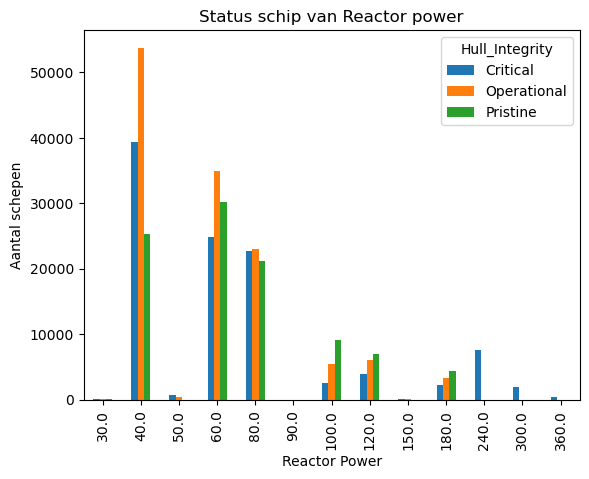

In [58]:
df.groupby('Reactor_Power')['Hull_Integrity'].value_counts().unstack().plot.bar()
plt.xlabel("Reactor Power")
plt.ylabel("Aantal schepen")
plt.title("Status schip van Reactor power")
plt.show()

In deze grafiek hebben wij een aantal dingen vastgesteld. De plasma thruster zijn het meeste critical. Dit zou kunnen betekenen dat daar de meeste schepen boven de 180 power hebben. De grafiek hieronder laat zien dat dat niet het geval is. Verder heeft de ion drive ook veel criticals dit komt waarschijnlijk omdat hier de meeste schepen van bestaan. Wat we verder kunnen zien is dat Antimatter heel veel pristine heeft vergeleken met critical en operational. Voor de graviton beam is dit hetzelfde. We kunnen dus met dit diagram en het diagram hieronder vaststellen welke hull Integrity elk type schip heeft en welke reactor power het vaakst voorkomt bij dit type schip. We zien hier verder niet echt veel bijzonders. Behalve dat bijna elk schipstype 40 of 60 Reactor power als hoogste waarde heeft. De hyper drive en nuclear Pulse zijn hier de uitzondering in met 80 reator power als hoogste waarde.

Wij hebben besloten deze 2 diagrammen er zo uit te laten zien omdat wij vinden dat je hier een makkelijk overzicht hebt.

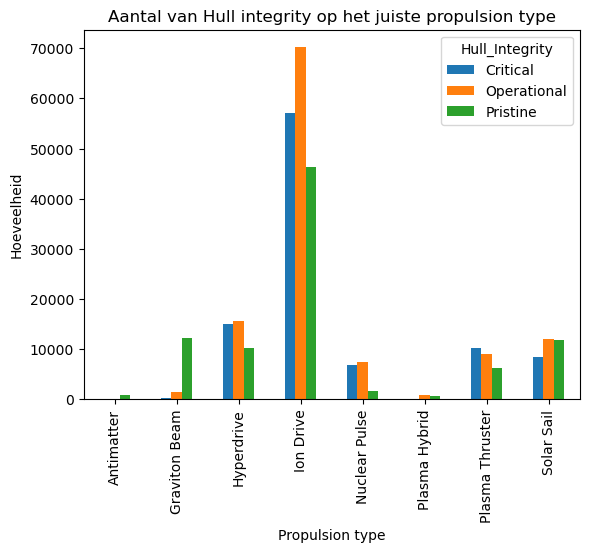

In [63]:
df.groupby('Propulsion_Type')['Hull_Integrity'].value_counts().unstack().plot.bar()
plt.xlabel("Propulsion type")
plt.ylabel("Hoeveelheid")
plt.title("Aantal van Hull integrity op het juiste propulsion type")
plt.show()

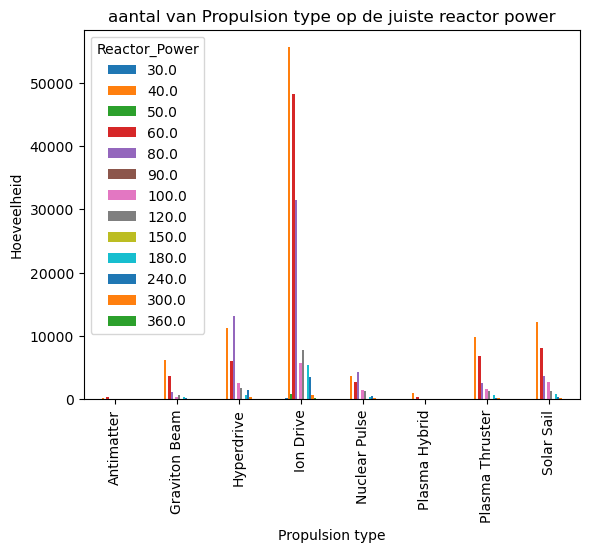

In [69]:
df.groupby('Propulsion_Type')['Reactor_Power'].value_counts().unstack().plot.bar()
plt.xlabel("Propulsion type")
plt.ylabel("Hoeveelheid")
plt.title("aantal van Propulsion type op de juiste reactor power")
plt.show()

**Data insights and data quality**
* **Insights:** What clear rules/patterns did you find that we can use for classification later?
* **Quality issues:** Document missing values (specifically in Propulsion and Reactor) and outliers.

Hier zie je dat de missende waardes in 2 kollommen zitten de Reactor_Power en de Propulsion_Type kollom.
Wij hebben besloten dit op deze manier te laten zien in een barplot omdat dit in onze ogen een makkelijk overzicht geeft
dat je in 1 oogopslag gelijk kan zien waar alle missende waardes zitten. Je zou dit ook kunnen doen zonder een grafiek te maken met df.isna().sum() dit geeft precies weer welke waardes er missen en hoeveel. Met deze informatie weten wij waar de missende waardes zitten en dat die vooral plaatsvinden in de Ion drive. 

<Axes: >

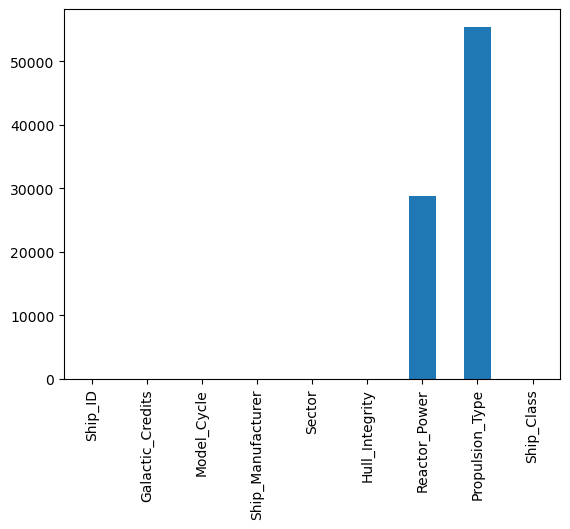

In [61]:
# CODE CELL: Generate visualizations (e.g., bar charts, boxplots comparing features against Hull_Integrity)
df.isna().sum().plot.bar()

Deze grafiek laat zien hoeveel schepen er bij elke Propulsion Type een missende reactor power hebben. Dit is handig om te weten omdat je kan zien dat de Ion drive heel veel meer mist dan de rest. Ook zie je dat antimatter heel weinig mist. Dit kan door verschillende oorzaken komen. Waarschijnlijk komt dit omdat de Ion drive veel meer van bestaat dan de rest.

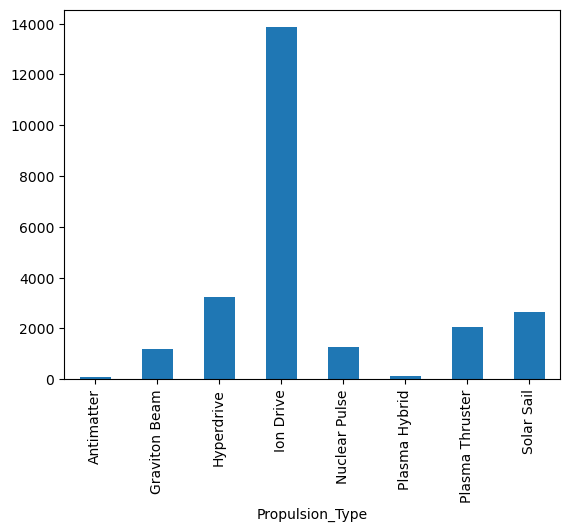

In [62]:
df['Reactor_Missing'] = df['Reactor_Power'].isna()
df.groupby('Propulsion_Type')['Reactor_Missing'].sum().plot.bar()
plt.show()


Met deze boxplots kan je outliers zien per Reactor power. Je ziet hier dat Critical de meeste en hoogste outliers heeft vergeleken met de andere types. Dit komt waarschijnlijk omdat de critical status vaak te maken heeft met een hoge Reactor power. Je kan dus vaststellen hiervan dat waarschijnlijk een hoge Reactor power te maken heeft met de critical score. Als je dit vergelijkt met het eerder gemaakt diagram dat gaat over critical score en reactor power weten wij nu zeker dat alle waardes boven de 180 reactor power critical zijn.

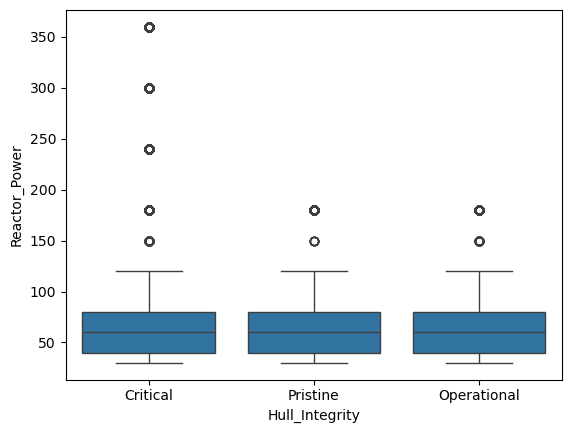

In [77]:
sns.boxplot(x='Hull_Integrity', y='Reactor_Power', data=df)

plt.show()

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [ ]:
# CODE CELL: Data cleaning, preprocessing

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [5]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [ ]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

In [1]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |